# Virtual Addressing

A program generates logical (virtual) addresses, not direct physical-memory addresses.

The translation path is:
- program issues a virtual address
- CPU/MMU translates it
- memory is accessed using the resulting physical address

So the process sees a convenient address space, while the OS and hardware decide where things really live.

This gives three major benefits:
- relocation: program can run anywhere in memory
- protection/isolation: one process cannot freely access another
- efficient use of memory: only needed parts have to be resident

---

### Why virtual memory exists

From the motivation slide, the reasons are:
- programs and data are stored in relatively slow secondary storage
- not all code/data is needed at once
- program size should not be limited by physical RAM size
- multiple programs may not all fit in memory together
- protection and isolation are needed
- virtual-machine style abstraction is useful

So virtual memory lets the system act as though each process has a large private memory, even if RAM is smaller and shared.

---

## 🟢 Segmentation
Segmentation divides a program into variable-sized logical units.

**Examples:**
- code
- global data
- heap
- stack
- procedures/modules
- locals/globals

This matches how programmers think about a program.

So segmentation is a logical memory organization.
---
### Variable-size blocks
Segments are not all the same size.

Different program parts naturally need different sizes:
- code segment may be large
- stack grows dynamically
- heap changes with allocation
- global data may be moderate
---
### Virtual address format for segmentation

A segmented address usually has two fields:
- segment number
- displacement (offset)

So the address means:
- “Go to segment s, then offset d within that segment.”
---
### Segment table
To translate a segmented address, the MMU consults a segment table.

A segment-table entry typically stores things like:
- present bit: is the segment in memory?
- size/limit: how large is the segment?
- protection: read/write/execute permissions
- base: where the segment starts in physical memory

Then translation works like this:
- use the segment number to index the segment table
- check whether the segment is valid/present
- check protection and bounds
- add the displacement to the base address
- access physical memory
---
### Nonlinear virtual space, nonlinear physical space

In segmentation:
- the process address space is divided into logical pieces
- those pieces do not have to be laid out as one flat linear block in physical memory

Each segment can live in a different place in RAM.

So both views are “nonlinear” in the sense that:
- different segments are separate logical entities
- physical placement can also be scattered
---
### Demand-segmented virtual memory
If a segment is not present in RAM, an access causes a fault.

Then software/OS:
- locates the segment on disk
- loads it into memory
- updates the segment table
- restarts the faulting instruction

This is demand loading at the segment level.
---
### Advantages of segmentation
- matches logical structure of programs
- supports natural protection by region
    - code: read/execute
    - data: read/write
    - stack: read/write
- supports sharing, such as shared code modules
- good for modular program organization
---
### Disadvantages of segmentation
- variable-size allocation causes external fragmentation
- segment management is more complex
- large segments can be hard to place contiguously
- compaction may be needed

So segmentation is great logically, but harder physically.

## 🟢 Paging
Paging divides memory into fixed-size pieces.
- code/data divided into equal FIXED sized pieces
- memory: page frames
- program: pages
Therefore:
- virtual memory is split into pages
- physical memory is split into frames of the same size

A page can be placed in any free frame.

This makes physical memory management much easier.
---
### Why paging is easier to manage
Because every block has the same size:
- no need to find a perfectly sized hole
- no external fragmentation from variable-size placement
- any page fits in any frame
---
### Virtual address format for paging
A paged virtual address has two parts:
- page number
- offset (displacement)
- 
So the address means:
- “Go to virtual page p, then offset d within that page.”
---
### Page table
To translate a paged address, the MMU uses a page table.

A page-table entry typically contains:
- present/valid bit
- frame number (base)
- protection bits
- dirty bit
- sometimes reference/use bits

Then translation works like this:
- use the page number to index the page table
- check whether the page is present
- check permissions
- get the frame number
- combine the frame number with the offset

Therefore:
physical address = frame base + offset
---
## Linear virtual space, nonlinear physical space

Contrasts paging with segmentation:
- virtual space appears linear
- physical space may still be scattered

This means the program sees one continuous address range:
- address 0, 1, 2, 3, ...

But page 0, 1, 2, 3 may live in very different physical frames.

So paging gives:
- linear virtual view
- nonlinear physical placement
---
## Demand-paged virtual memory
If a referenced page is not present:
- a page fault occurs
- OS loads that page from disk into a frame
- updates the page table
- restarts the instruction

This is the most common modern virtual-memory technique.
---
## Advantages of paging
- simple physical allocation
- eliminates external fragmentation
- easy frame replacement policies
- supports large virtual address spaces
- works well with demand loading
---
## Disadvantages of paging
- internal fragmentation within the last page
- large page tables
- every memory access needs translation
- page faults are expensive
- without caching translation, performance would suffer badly

---

## 🟢 Page Size Calculation
Scenario:
- 32-bit virtual address
- 8 MB real memory
- 4 KB page size
---
### Virtual pages
- Page size = 4 KB = 2^12 bytes
- A 32-bit virtual address space contains: 2^32 bytes total
- So number of virtual pages is: 2^32 / 2^12 = 2^20

So there are:
- 1,048,576 virtual pages
---
### Real-memory address size
8 MB = 2^23 bytes

So a physical address needs: 23 bits
---
### Real page frame address bits
Each frame is 4 KB = 2^12

So number of physical frames is: 2^23 / 2^12 = 2^11

So there are:
- 2048 frames

To identify a frame, you need:
- 11 bits
---
### Physical address split
Physical address = frame number + offset
- frame bits = 11
- offset bits = 12

Total = 23 bits
---
### Page-table size intuition

If there are 2^20 virtual pages, then a simple one-level page table needs:
- about a million entries
- 4 GB memory with 4 KB pages gives around 2^20 entries

This is why page tables can get large.

## 🟢Mapping from virtual to physical memory

Virtual address:
- segment or page number
- displacement

The number part selects a table entry.

The table entry contains metadata such as:
- present
- size
- protection
- base

Then hardware uses that information to compute the physical address:
- **Hardware:** check table every access
- **Software:** manage table, respond to faults

That is the key mechanism vs policy split.

---

## 🟢 Mechanism vs policy
### Hardware = mechanism
Hardware/MMU does the fast per-access work:
- interprets address fields
- checks tables
- enforces bounds and protection
- translates virtual to physical
- raises faults if translation fails

This must be hardware because it happens on every memory reference.

### OS = policy
Software/OS decides:
- what entries go into the tables
- what to load into memory
- what to evict on faults
- what protections to assign
- how to organize backing storage on disk

---

## 🟢 Segmentation and paging together
- use the segment field to index the segment table
- segment entry tells where the relevant page table is, along with protection and size info
- use the page field to index that page table
- page-table entry gives the physical frame
- add displacement to form physical address

So the segment table defines the logical object, and the page table manages its physical placement.

### Advantage
Because the combination gets the benefits of both:

#### From segmentation
- logical program structure
- flexible protection
- separate code/data/stack regions
- modularity and sharing

#### From paging
- fixed-size physical allocation
- no external fragmentation at the frame level
- efficient memory management

#### So the combination is:
- segmentation for meaning
- paging for implementation efficiency

---

## 🟢 Multilevel Paging

A single, flat page table can be very large, because it needs one entry for every possible virtual page, even if most of those pages are never used.

**Multilevel paging** solves this by breaking one large page table into a hierarchy of smaller tables.

So instead of:
- one huge page table for the whole virtual address space

we use:
- a top-level table pointing to lower-level tables
- lower-level tables created only when needed

This saves memory because unused regions of the virtual address space do not need full page tables.

---

### One-level interpretation

If the address format is:
- page
- offset

and offset is 12 bits because page size is 4 KB, then the remaining higher bits identify the virtual page.

If one page table contains 512 entries, then 9 bits can index one table.

So one small page table handles 2 MB of address space.

If a process needs more than 2 MB, you need another such page table.

That leads to the next question:
- where is this second page table?
- Answer: in another, higher-level table.

That is exactly how multilevel paging begins.

---

### Two-level interpretation

Suppose you need more than one page table.

Then split the page number into:
- outer index
- inner index

Example:
- outer index chooses which page table
- inner index chooses the entry within that page table
- offset chooses the byte within the page

So the address becomes conceptually:
- directory
- table
- offset

Translation becomes:
- use directory bits to find the correct page table
- use table bits to find the page-table entry
- use offset bits inside the final page

---

### Extending to more levels

For very large address spaces, even the “directory of page tables” may itself be too large.

So we repeat the idea.

That produces multiple levels such as:
- PML4
- Directory Pointer
- Directory
- Table
- Offset

This is what the 64-bit example slide is showing.

Each level contains:
- 512 entries = 2^9
- because each table fits in one 4 KB page, and each entry is 8 bytes: 4096 / 8 = 512

So every table level consumes one page and is indexed by 9 bits.

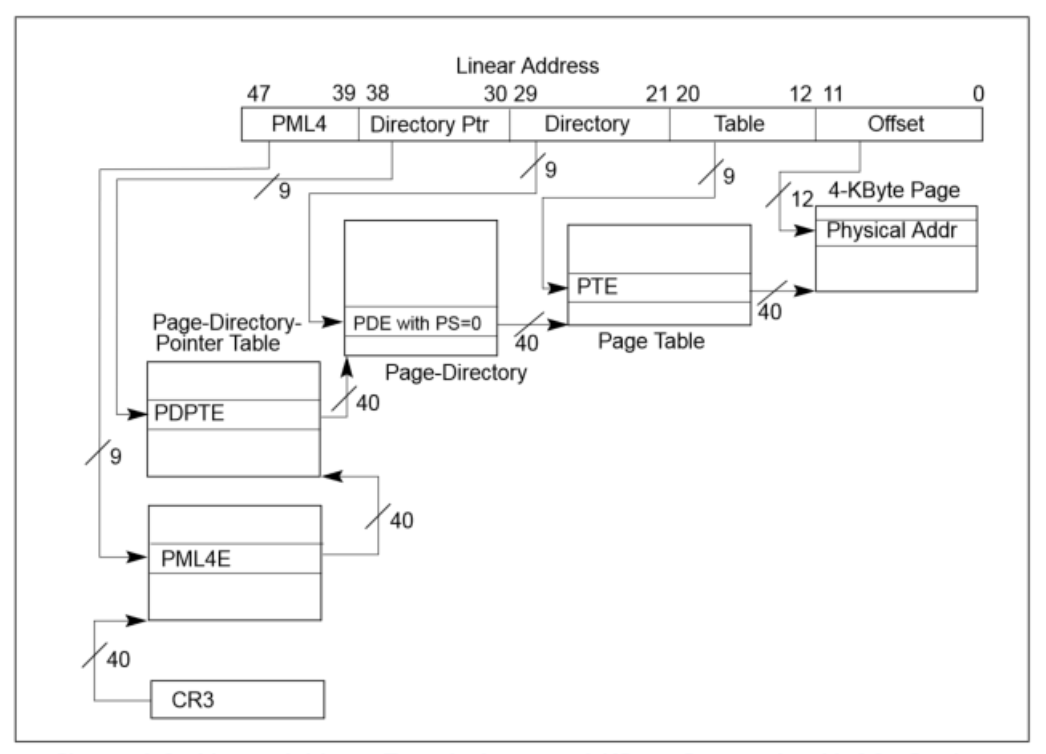

### 48-bit virtual address breakdown

The slides show a 48-bit linear address broken as:
- bits 47–39: PML4
- bits 38–30: Directory Pointer
- bits 29–21: Directory
- bits 20–12: Table
- bits 11–0: Offset

That is:
- 9 bits
- 9 bits
- 9 bits
- 9 bits
- 12 bits

Total: `9+9+9+9+12=48`

So each memory access conceptually walks 4 table levels and then applies the final 12-bit page offset.

### Why each level has 512 entries

Because:
- page size = 4 KB = 4096 bytes
- page-table entry size = 8 bytes
- entries per page table:

`4096 / 8 = 512 = 2^9`

That is why each table level is indexed by exactly 9 bits.

### Page Walk
For a 48-bit virtual address, translation works like this:
- use the PML4 field to select one entry in the top-level table
- that entry points to a Directory Pointer Table
- use the Directory Ptr field to select one entry there
- that entry points to a Directory
- use the Directory field to select one entry there
- that entry points to a Page Table
- use the Table field to select one entry there
- that entry gives the physical frame number
- combine it with the Offset to form the physical address

So it is a sequence of indexed lookups through a tree of tables.

---